In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def forward(X, theta):
    a = theta[:, 0]  # (N,)
    W = theta[:, 1:-1]  # (N, input_dim)
    b = theta[:, -1]  # (N,)
    z = X @ W.T + b  # (M, N) --  X: (M, input_dim), W^T: (input_dim, N) 
    relu_z = np.maximum(0, z)  # (M, N)
    y_pred = np.mean(a * relu_z, axis=1)  # (M,)
    return y_pred, z

def loss_fn(X, Y, theta, lam):
    y_pred, z = forward(X, theta)
    error = np.mean((y_pred - Y)**2)
    reg = lam * np.mean(np.sum(theta**2, axis=1))
    return error + reg

In [3]:
input_dim = 1
D = input_dim + 2  # dim_theta_i

In [4]:
def train(X_data, Y_data, N=1000, step_size=5, lam=0, beta=np.inf, init_scale = .01, 
    max_iter=int(1e6), seed=0, tracktrain=False, num_traj=1000, tol = 1e-8):

    # sk = step_size / N

    input_dim = X_data.shape[1]
    D = input_dim + 2
    np.random.seed(seed)
    theta = np.random.randn(N, D) * init_scale
    initdata = theta.copy()
    traj_data = []
    
    for iter in range(max_iter):
        idx = np.random.randint(0, X_data.shape[0])
        x_train = X_data[idx,:].reshape(1,input_dim) # (1,input_dim)
        y_train = Y_data[idx]  # (1,)
        y_pred, z = forward(x_train, theta)
        error = y_pred - y_train # (1,)
        relu_z = np.maximum(0, z) # (1,N)

        a = theta[:, 0]  # (N,)
        grad_a = 2 * (error * relu_z).reshape(-1,) # (N,)
        d_relu_z = (z > 0).astype(float).reshape(-1,) # (N,1)
        coef = 2 * error * a * d_relu_z  # (N,)    ai * sigma'(wi^T x + bi)
        grad_w = coef.reshape(-1, 1) @ x_train  # (N,d)
        grad_b = coef.reshape(-1)  # (N,)

        theta_old = theta.copy()

        theta[:, 0] -= step_size * grad_a * 1/N
        theta[:, 1:-1] -= step_size * grad_w * 1/N
        theta[:, -1] -= step_size * grad_b * 1/N
        
        theta -= 2 * (step_size / N) * lam * theta_old
        
        
        loss = loss_fn(X_data, Y_data, theta, lam=lam)
        if (iter + 1) % 1000 == 0:
            print(f"Iter {iter+1:3d}/{max_iter}, Loss: {loss:.10f}")
        if loss < tol:
            break

        if iter % num_traj == 0:
            traj_data.append(theta.copy())

    if tracktrain:
        return theta, initdata, traj_data
    else:   
        return theta
        

In [5]:
X_data = np.array([[-2.0], [2.0]])
Y_data = np.array([1.0, -1.0])

train_theta_odd_big = train(X_data, Y_data, tracktrain=False, N=1000, 
    step_size=1, init_scale=0.0001, max_iter=int(1e6), lam=0.01, tol = 1e-8)

Iter 1000/1000000, Loss: 0.9999991949
Iter 2000/1000000, Loss: 0.9999321897
Iter 3000/1000000, Loss: 0.9941752339
Iter 4000/1000000, Loss: 0.6522244012
Iter 5000/1000000, Loss: 0.0221983780
Iter 6000/1000000, Loss: 0.0178093171
Iter 7000/1000000, Loss: 0.0178085806
Iter 8000/1000000, Loss: 0.0178088711
Iter 9000/1000000, Loss: 0.0178085444
Iter 10000/1000000, Loss: 0.0178085457
Iter 11000/1000000, Loss: 0.0178093849
Iter 12000/1000000, Loss: 0.0178086041
Iter 13000/1000000, Loss: 0.0178088693
Iter 14000/1000000, Loss: 0.0178092846
Iter 15000/1000000, Loss: 0.0178085488
Iter 16000/1000000, Loss: 0.0178085974
Iter 17000/1000000, Loss: 0.0178087053
Iter 18000/1000000, Loss: 0.0178085441
Iter 19000/1000000, Loss: 0.0178086412
Iter 20000/1000000, Loss: 0.0178087778
Iter 21000/1000000, Loss: 0.0178091587
Iter 22000/1000000, Loss: 0.0178085515
Iter 23000/1000000, Loss: 0.0178092206
Iter 24000/1000000, Loss: 0.0178085991
Iter 25000/1000000, Loss: 0.0178085443
Iter 26000/1000000, Loss: 0.017808

In [6]:
X_data = np.array([[-1/3], [1/3.]])
Y_data = np.array([1.0, -1.0])

train_theta_odd_small = train(X_data, Y_data, tracktrain=False, N=1000, 
    step_size=1, init_scale=0.0001, max_iter=int(1e6), lam=0.01, tol = 1e-8)

Iter 1000/1000000, Loss: 0.9999999951
Iter 2000/1000000, Loss: 0.9999999811
Iter 3000/1000000, Loss: 0.9999999339
Iter 4000/1000000, Loss: 0.9999997735
Iter 5000/1000000, Loss: 0.9999992263
Iter 6000/1000000, Loss: 0.9999973824
Iter 7000/1000000, Loss: 0.9999910636
Iter 8000/1000000, Loss: 0.9999694546
Iter 9000/1000000, Loss: 0.9998967333
Iter 10000/1000000, Loss: 0.9996500991
Iter 11000/1000000, Loss: 0.9988289792
Iter 12000/1000000, Loss: 0.9960076638
Iter 13000/1000000, Loss: 0.9866958960
Iter 14000/1000000, Loss: 0.9562124865
Iter 15000/1000000, Loss: 0.8626419140
Iter 16000/1000000, Loss: 0.6350270437
Iter 17000/1000000, Loss: 0.3079594301
Iter 18000/1000000, Loss: 0.1144235469
Iter 19000/1000000, Loss: 0.0687279202
Iter 20000/1000000, Loss: 0.0628862800
Iter 21000/1000000, Loss: 0.0623070665
Iter 22000/1000000, Loss: 0.0622533569
Iter 23000/1000000, Loss: 0.0622532060
Iter 24000/1000000, Loss: 0.0622499758
Iter 25000/1000000, Loss: 0.0622490666
Iter 26000/1000000, Loss: 0.062247

In [7]:
X_data = np.array([[-2], [2]])
Y_data = np.array([1,1])

train_theta_even_big = train(X_data, Y_data, tracktrain=False, N=1000, 
    step_size=1, init_scale=0.0001, max_iter=int(1e6), lam=0.01, tol = 1e-8)

Iter 1000/1000000, Loss: 0.9999992683
Iter 2000/1000000, Loss: 0.9999412531
Iter 3000/1000000, Loss: 0.9951129532
Iter 4000/1000000, Loss: 0.6947315855
Iter 5000/1000000, Loss: 0.0237964093
Iter 6000/1000000, Loss: 0.0179011398
Iter 7000/1000000, Loss: 0.0178988000
Iter 8000/1000000, Loss: 0.0178978463
Iter 9000/1000000, Loss: 0.0178962565
Iter 10000/1000000, Loss: 0.0178950625
Iter 11000/1000000, Loss: 0.0178947613
Iter 12000/1000000, Loss: 0.0178928410
Iter 13000/1000000, Loss: 0.0178920198
Iter 14000/1000000, Loss: 0.0178913842
Iter 15000/1000000, Loss: 0.0178896079
Iter 16000/1000000, Loss: 0.0178886628
Iter 17000/1000000, Loss: 0.0178878070
Iter 18000/1000000, Loss: 0.0178866992
Iter 19000/1000000, Loss: 0.0178858915
Iter 20000/1000000, Loss: 0.0178851442
Iter 21000/1000000, Loss: 0.0178846548
Iter 22000/1000000, Loss: 0.0178832057
Iter 23000/1000000, Loss: 0.0178830820
Iter 24000/1000000, Loss: 0.0178816532
Iter 25000/1000000, Loss: 0.0178808204
Iter 26000/1000000, Loss: 0.017880

In [8]:
X_data = np.array([[-1/3], [1/3]])
Y_data = np.array([1,1])

train_theta_even_small = train(X_data, Y_data, tracktrain=False, N=1000, 
    step_size=1, init_scale=0.0001, max_iter=int(1e6), lam=0.01, tol = 1e-8)

Iter 1000/1000000, Loss: 0.9999998024
Iter 2000/1000000, Loss: 0.9999896616
Iter 3000/1000000, Loss: 0.9994599522
Iter 4000/1000000, Loss: 0.9723670465
Iter 5000/1000000, Loss: 0.3385744086
Iter 6000/1000000, Loss: 0.0204895088
Iter 7000/1000000, Loss: 0.0199004014
Iter 8000/1000000, Loss: 0.0199000785
Iter 9000/1000000, Loss: 0.0199000697
Iter 10000/1000000, Loss: 0.0199000505
Iter 11000/1000000, Loss: 0.0199000874
Iter 12000/1000000, Loss: 0.0199000377
Iter 13000/1000000, Loss: 0.0199000815
Iter 14000/1000000, Loss: 0.0199001382
Iter 15000/1000000, Loss: 0.0199000607
Iter 16000/1000000, Loss: 0.0199000290
Iter 17000/1000000, Loss: 0.0199000121
Iter 18000/1000000, Loss: 0.0199000023
Iter 19000/1000000, Loss: 0.0199000009
Iter 20000/1000000, Loss: 0.0199000057
Iter 21000/1000000, Loss: 0.0199000410
Iter 22000/1000000, Loss: 0.0199000196
Iter 23000/1000000, Loss: 0.0199000319
Iter 24000/1000000, Loss: 0.0199000025
Iter 25000/1000000, Loss: 0.0199000008
Iter 26000/1000000, Loss: 0.019900

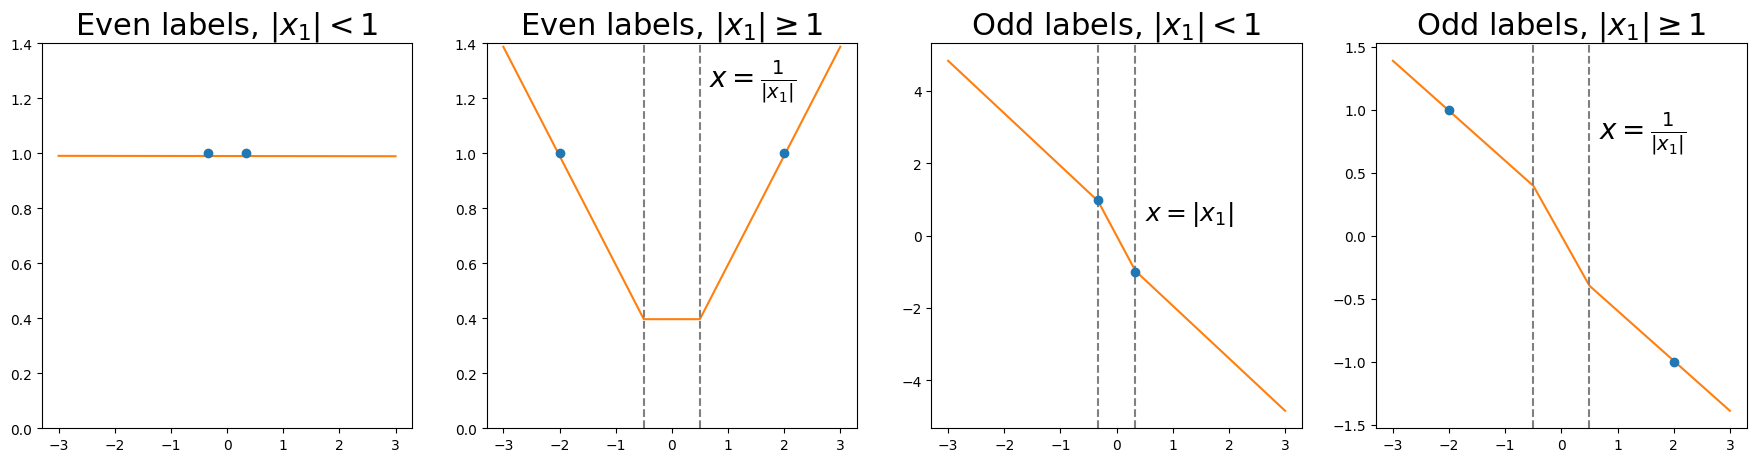

In [11]:
fig,ax = plt.subplots(1,4,figsize=(22,5))

FS = 22

xxx = np.linspace(-3, 3, 500).reshape(500, 1)

yyy, _ = forward(xxx, train_theta_odd_big)
ax[3].plot(xxx,yyy,c='tab:orange')
ax[3].scatter(np.array([[-2.0], [2.0]]),np.array([1,-1]),zorder=30)
ax[3].axvline(x=1/2, linestyle='--',c='grey')
ax[3].axvline(x=-1/2, linestyle='--',c='grey')
ax[3].text(2/3, 1, r"$x=\frac{1}{| x_1 |}$", color='black', 
           va='top', ha='left', fontsize=20, backgroundcolor='white')
ax[3].set_title(r"Odd labels, $|x_1|\geq 1$", fontsize=FS)

yyy, _ = forward(xxx, train_theta_odd_small)
ax[2].plot(xxx,yyy,c='tab:orange')
ax[2].scatter(np.array([[-1/3.0], [1/3.0]]),np.array([1,-1]),zorder=30)#, s=30)
ax[2].axvline(x=1/3, linestyle='--',c='grey')
ax[2].axvline(x=-1/3, linestyle='--',c='grey')
ax[2].text(1/2, 1, r"$x=|x_1|$", color='black', 
           va='top', ha='left', fontsize=18, backgroundcolor='white')
ax[2].set_title(r"Odd labels, $|x_1|<1$", fontsize=FS)

yyy, _ = forward(xxx, train_theta_even_big)
ax[1].plot(xxx,yyy,c='tab:orange')
ax[1].scatter(np.array([[-2.0], [2.0]]),np.array([1,1]),zorder=30)#, s=30)
ax[1].axvline(x=1/2, linestyle='--',c='grey')
ax[1].axvline(x=-1/2, linestyle='--',c='grey')
ax[1].text(2/3, 1.35, r"$x=\frac{1}{| x_1 |}$", color='black', 
           va='top', ha='left', fontsize=20, backgroundcolor='white')
ax[1].set_ylim([0,1.4])
ax[1].set_title(r"Even labels, $|x_1|\geq 1$", fontsize=FS)

yyy, _ = forward(xxx, train_theta_even_small)
ax[0].plot(xxx,yyy,c='tab:orange')
ax[0].scatter(np.array([[-1/3], [1/3]]),np.array([1,1]),zorder=30)#, s=30)
ax[0].set_ylim([0,1.4])
ax[0].set_title(r"Even labels, $|x_1|<1$", fontsize=FS)

plt.savefig("Fig/1D.png", dpi=300, bbox_inches='tight')